In [10]:

#librerias esenciales cuando trabajamos con datos
import pandas as pd
import numpy as np

#Extensiones para temas graficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go


In [14]:
#configuración grafica
plt.style.use('seaborn-v0_8-whitegrid') #Estilo de las graficas matplotlib
sns.set_style("whitegrid") #Estilo de las graficas seaborn
plt.rcParams['figure.figsize'] = (12,4) #Tamaño del titulo de los ejes

In [15]:
#Cargar nuestra data
df = pd.read_csv(r"data\titanic_limpio.csv")

In [17]:
#mostramos la data
df.head(2)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin datos,S,0
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


In [18]:
#Crear una variable especifica que contenga la información que queremos en nuestro grafico
supervivientes_por_clase = df.groupby('Pclass')['Survived'].mean()* 100

In [22]:
supervivientes_por_clase

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

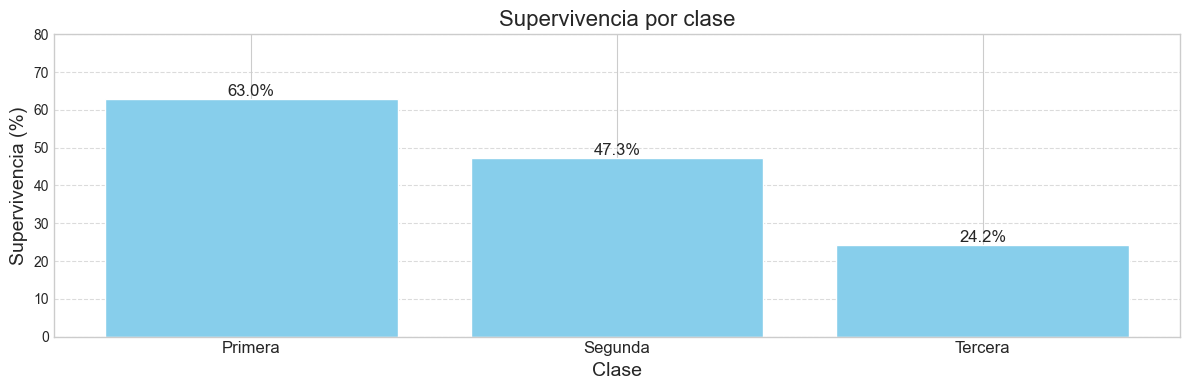

In [32]:
plt.figure(figsize=(12,4))
#crea el grafico de barras
bars = plt.bar(supervivientes_por_clase.index, supervivientes_por_clase.values, color='skyblue')
#añadir etiquetas a las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=12)
#añadir etiquetas y titulos
plt.title('Supervivencia por clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Supervivencia (%)', fontsize=14)
plt.xticks(supervivientes_por_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.ylim(0, 80)
#anadimos una cuadricula
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() #ajustar el grafico
plt.show() #mostrar el grafico

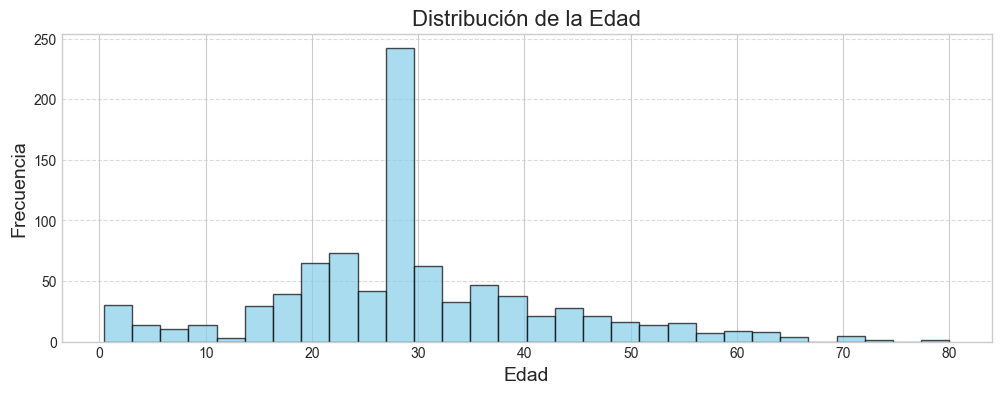

In [33]:
### hist plost (histograma)
plt.figure(figsize=(12,4))
edad = df['Age'].dropna()  # Eliminar valores NaN de la columna 'Age'
n, bins, patches = plt.hist(edad, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Edad', fontsize=16)
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() #mostrar el grafico
 

In [34]:
#Cargar nuestra data
df = pd.read_csv(r"data\titanic.csv")

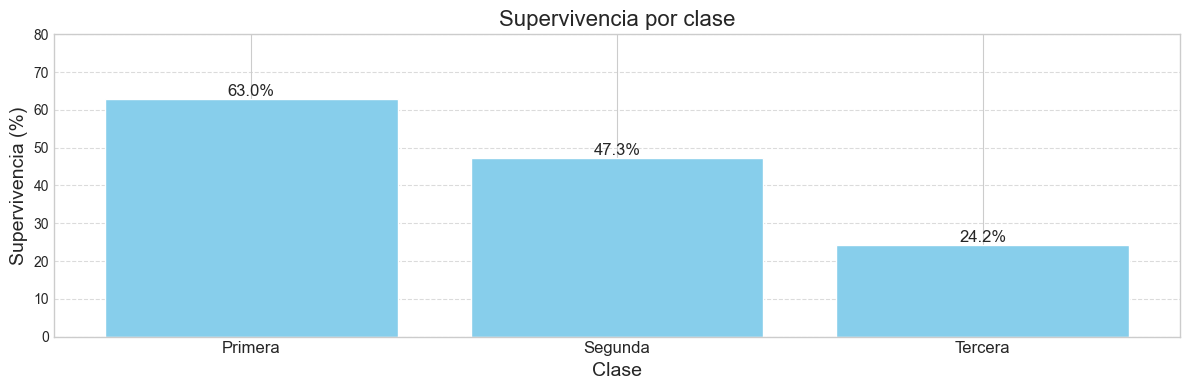

In [35]:
plt.figure(figsize=(12,4))
#crea el grafico de barras
bars = plt.bar(supervivientes_por_clase.index, supervivientes_por_clase.values, color='skyblue')
#añadir etiquetas a las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=12)
#añadir etiquetas y titulos
plt.title('Supervivencia por clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Supervivencia (%)', fontsize=14)
plt.xticks(supervivientes_por_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.ylim(0, 80)
#anadimos una cuadricula
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() #ajustar el grafico
plt.show() #mostrar el grafico

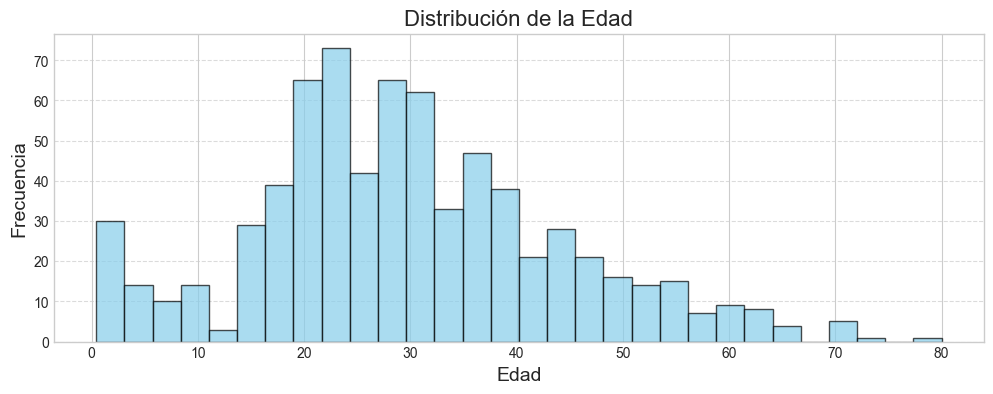

In [36]:
### hist plost (histograma)
plt.figure(figsize=(12,4))
edad = df['Age'].dropna()  # Eliminar valores NaN de la columna 'Age'
n, bins, patches = plt.hist(edad, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Edad', fontsize=16)
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() #mostrar el grafico

### Diagrama de dispersión

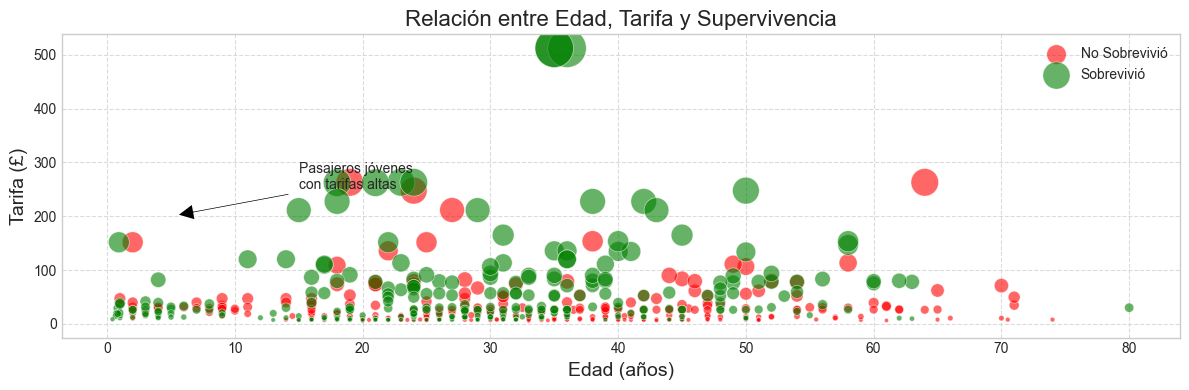

In [37]:
plt.figure(figsize=(12,4))
for survived, color, label in zip([0, 1], ['red', 'green'], ['No Sobrevivió', 'Sobrevivió']):
    # Filtrar datos
    subset = df[df['Survived'] == survived]
    
    # Crear el gráfico de dispersión
    plt.scatter(subset['Age'], subset['Fare'], 
                c=color, alpha=0.6, edgecolors='w', linewidth=0.5,
                label=label, s=subset['Fare']*1.5)  # Tamaño proporcional a la tarifa

# Añadir títulos y etiquetas
plt.title('Relación entre Edad, Tarifa y Supervivencia', fontsize=16)
plt.xlabel('Edad (años)', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Anotaciones para contexto
plt.annotate('Pasajeros jóvenes \ncon tarifas altas', 
             xy=(5, 200), xytext=(15, 250),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

plt.tight_layout()
plt.show()

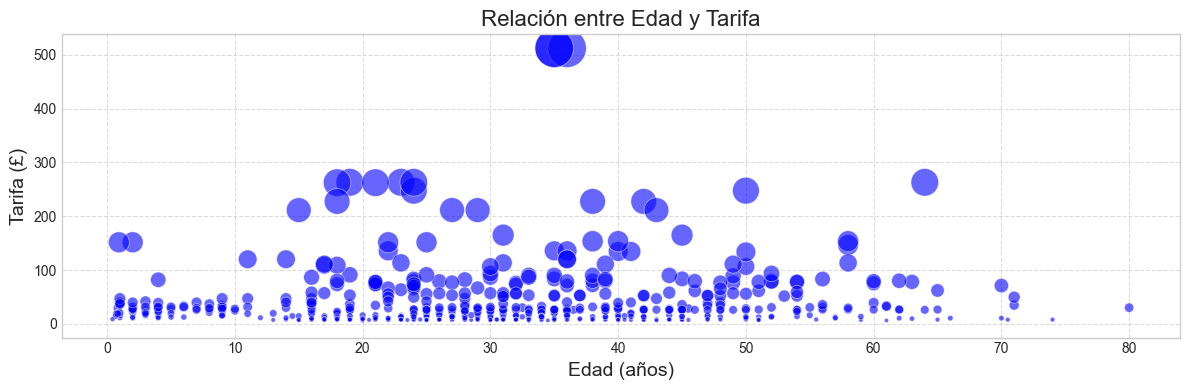

In [43]:
plt.figure(figsize=(12, 4))

# Crear el gráfico de dispersión
plt.scatter(df['Age'], df['Fare'], 
            c='blue', alpha=0.6, edgecolors='w', linewidth=0.5, s=df['Fare']*1.5)

# Añadir títulos y etiquetas
plt.title('Relación entre Edad y Tarifa', fontsize=16)
plt.xlabel('Edad (años)', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


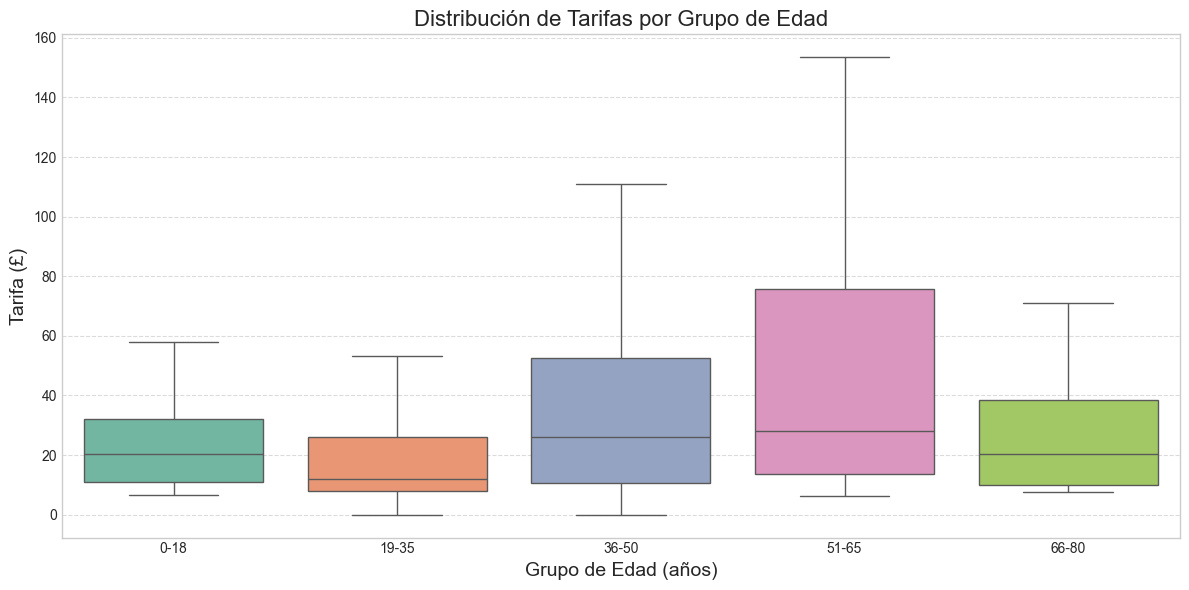

In [45]:
# Crear el gráfico combinado
plt.figure(figsize=(12, 6))
sns.boxplot(x='AgeGroup', y='Fare', hue='AgeGroup', data=df, palette='Set2', showfliers=False, dodge=False, legend=False)  # Boxplot sin outliers

# Añadir títulos y etiquetas
plt.title('Distribución de Tarifas por Grupo de Edad', fontsize=16)
plt.xlabel('Grupo de Edad (años)', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)

# Añadir una cuadrícula
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Correlación

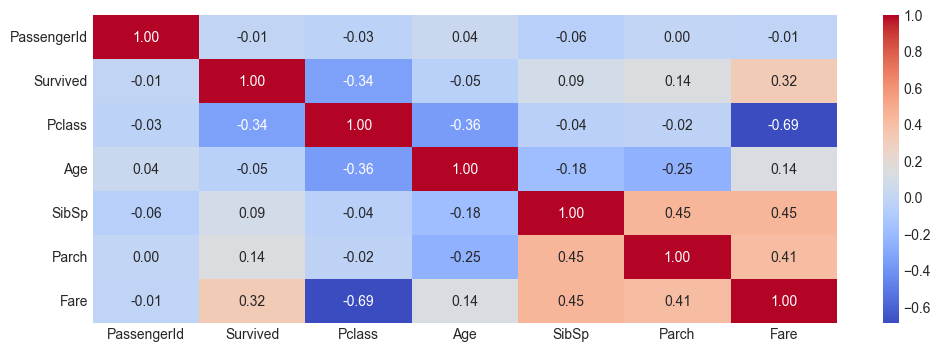

In [39]:
#creamos la variable que contenga la matriz de correlación
corr_matrix = df.select_dtypes(include=[np.number]).corr(method='spearman')
#creo la figura
plt.Figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show() #mostrar el grafico

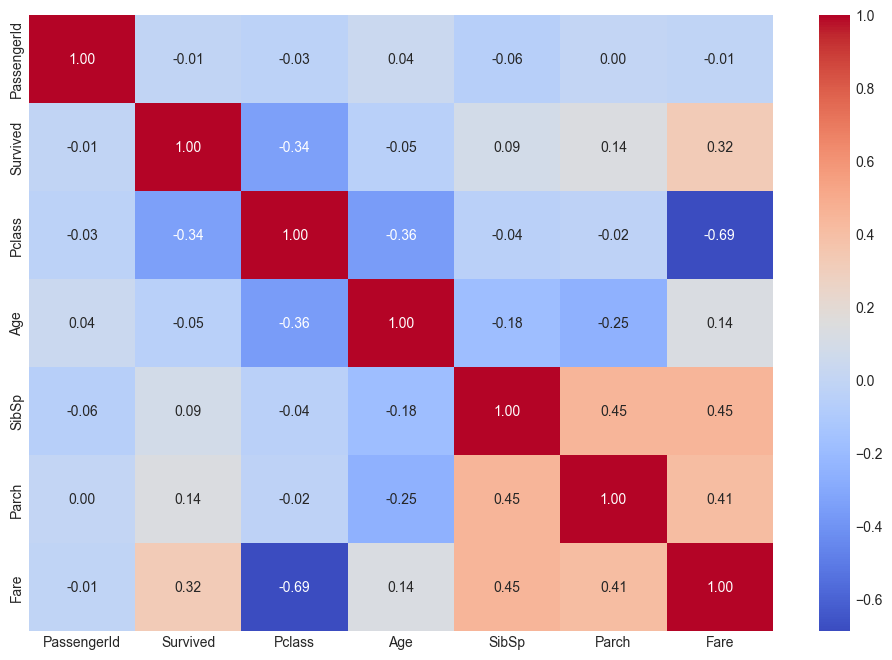

In [42]:
corr_matrix = df.select_dtypes(include=[np.number]).corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

<Axes: >

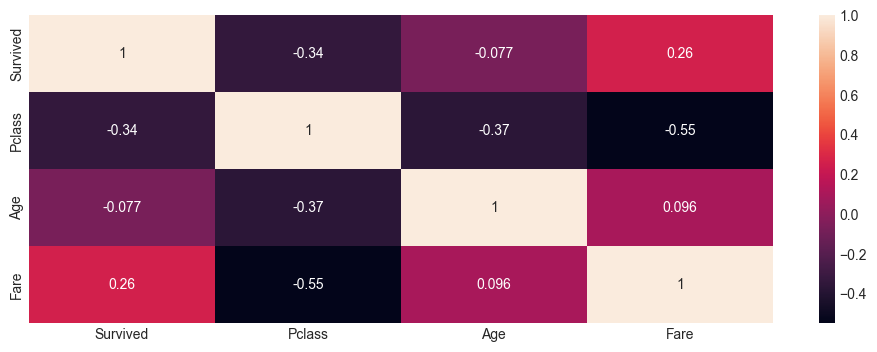

In [41]:
correlaciones = df[['Survived', 'Pclass', 'Age' , 'Fare']]
sns.heatmap(correlaciones.corr(), annot=True)

### Boxplot (grafico muy importante, se usa mucho)

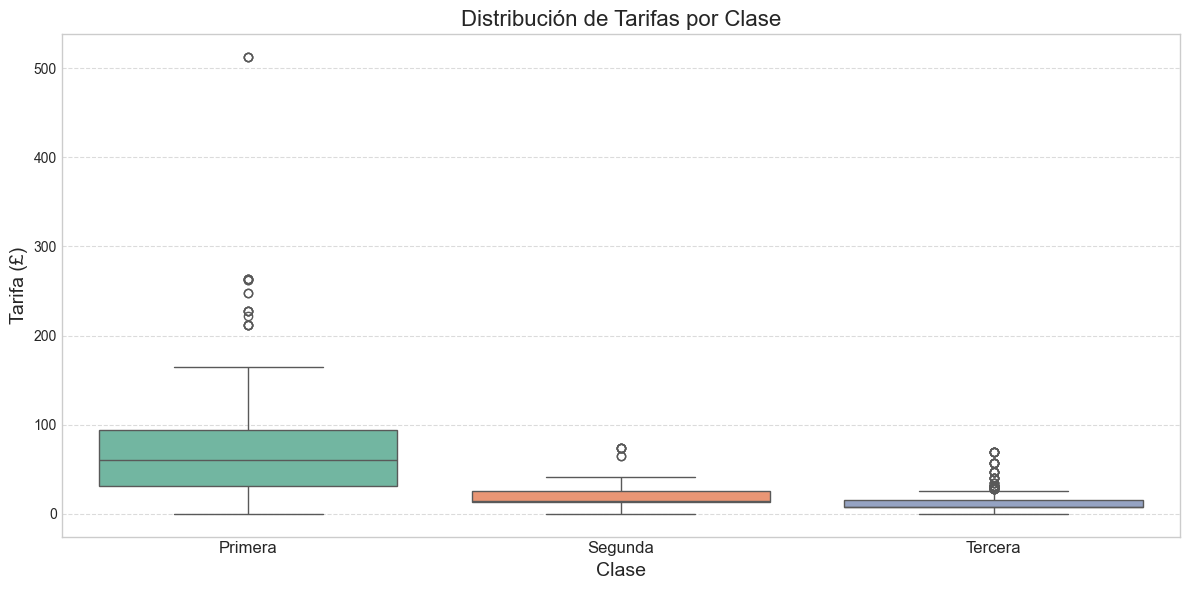

In [40]:
# Crea un boxplot para visualizar la distribución de las tarifas por clase
plt.figure(figsize=(12, 6))
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='Set2', dodge=False, legend=False)
plt.title('Distribución de Tarifas por Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)
plt.xticks([0, 1, 2], ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()  # Mostrar el gráfico

<Axes: xlabel='Age', ylabel='Fare'>

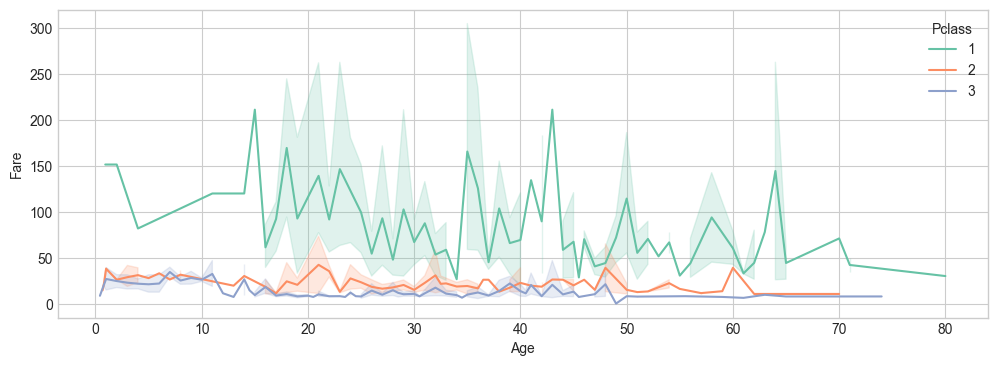

In [47]:
sns.lineplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Pclass',
    palette='Set2',
    markers=True,
    dashes=False

)

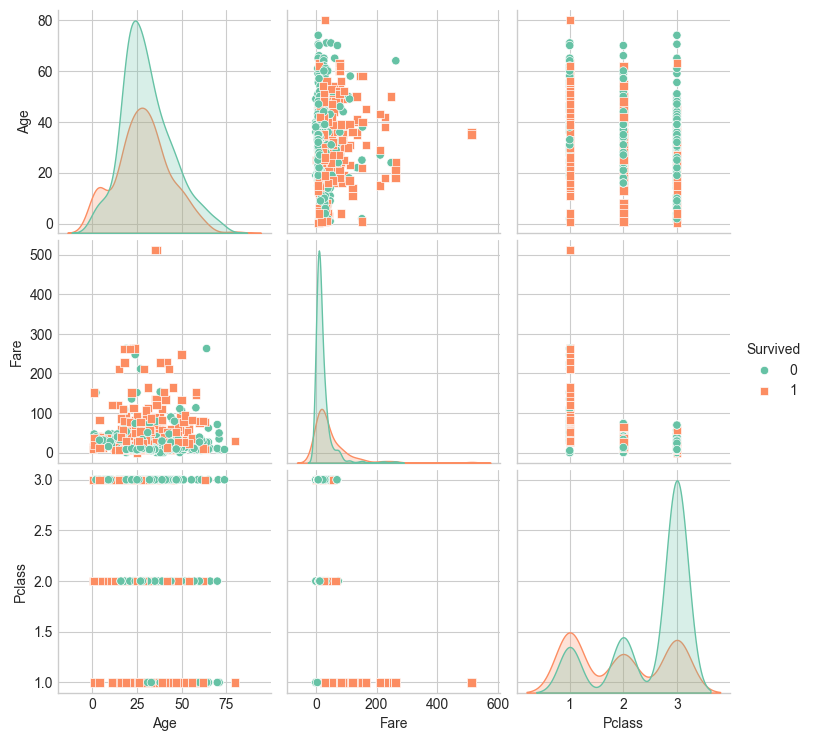

In [48]:
sns.pairplot(
    df,
    hue='Survived',
    vars=['Age', 'Fare', 'Pclass'],
    palette='Set2',
    diag_kind='kde',
    markers=["o", "s"],
    
)

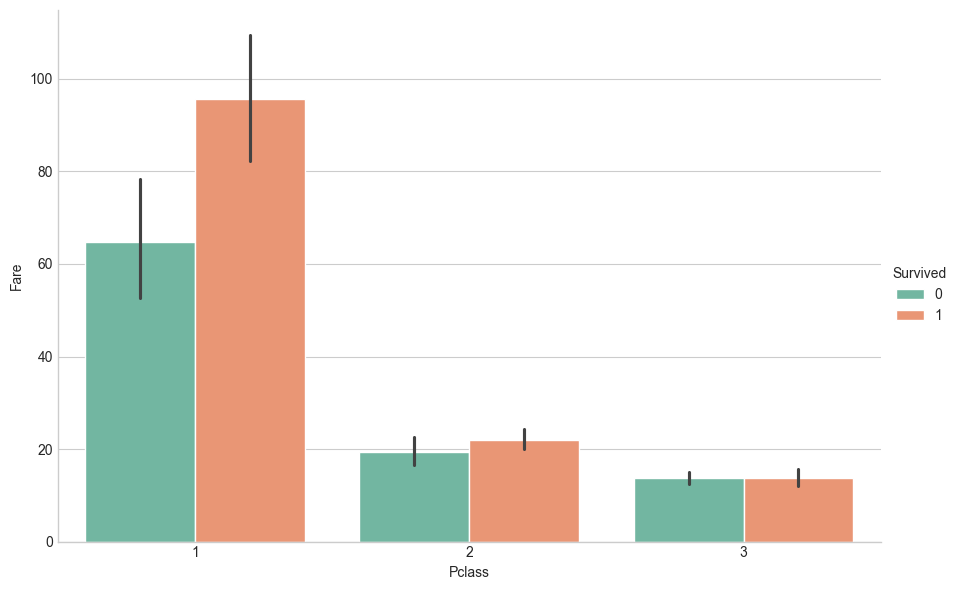

In [ ]:
sns.catplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived', #leyenda
    kind='bar',
    palette='Set2',
    height=6,
    aspect=1.5,
)

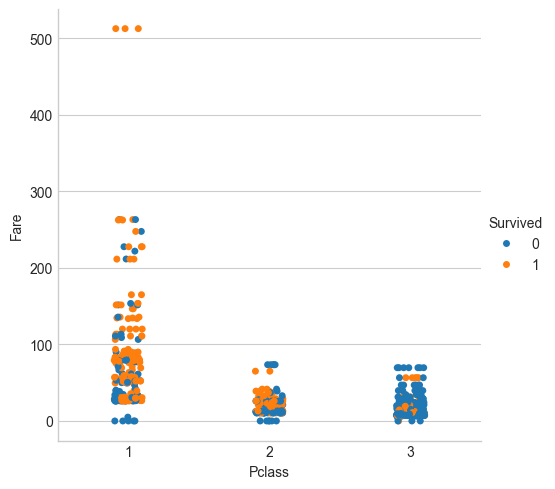

In [51]:
sns.catplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived', #leyenda
)

<Axes: xlabel='Pclass', ylabel='Fare'>

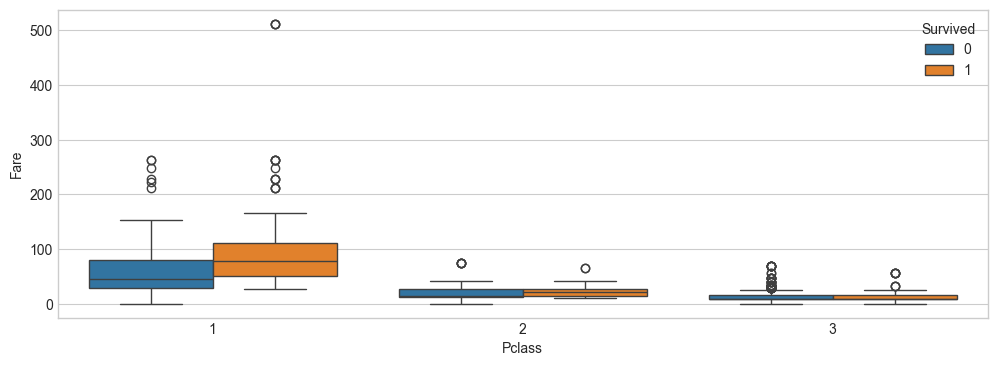

In [52]:
sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived', #leyenda
    
)

<Axes: xlabel='Pclass', ylabel='Survived'>

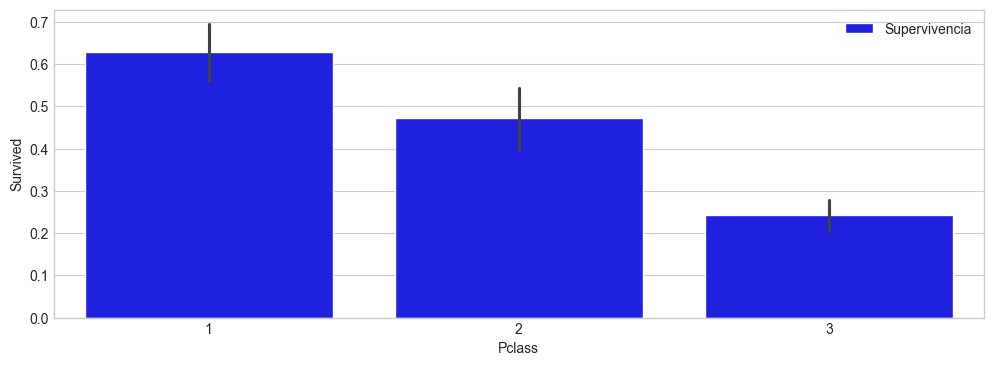

In [55]:
sns.barplot(x='Pclass', y='Survived',
             data=df, label='Supervivencia', color='blue')


In [58]:
df2 = pd.read_csv(r"data\titanic.csv")

In [ ]:
df2.isnull().sum()  # Verificamos si hay valores nulos en la data


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

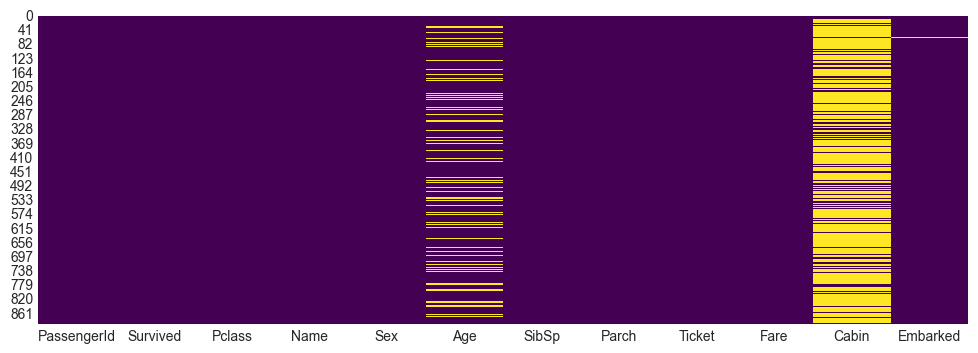

In [60]:
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')

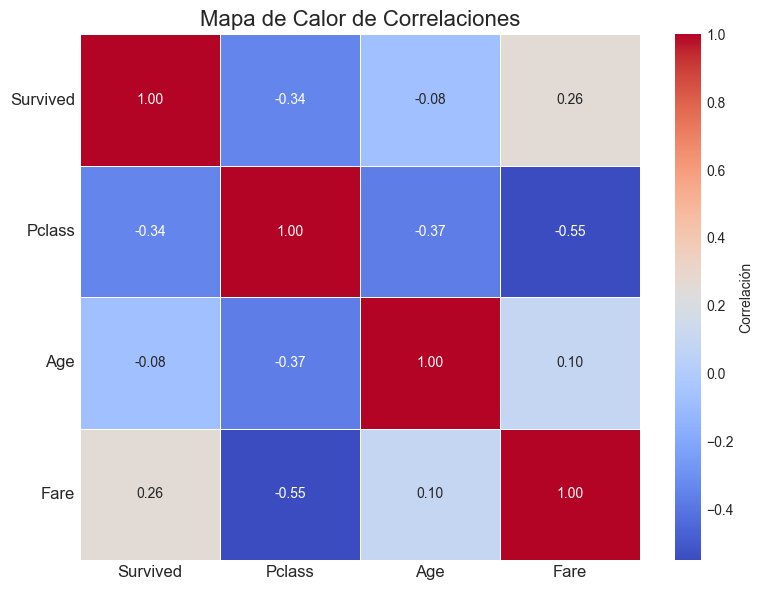

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlaciones.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlación'}, linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

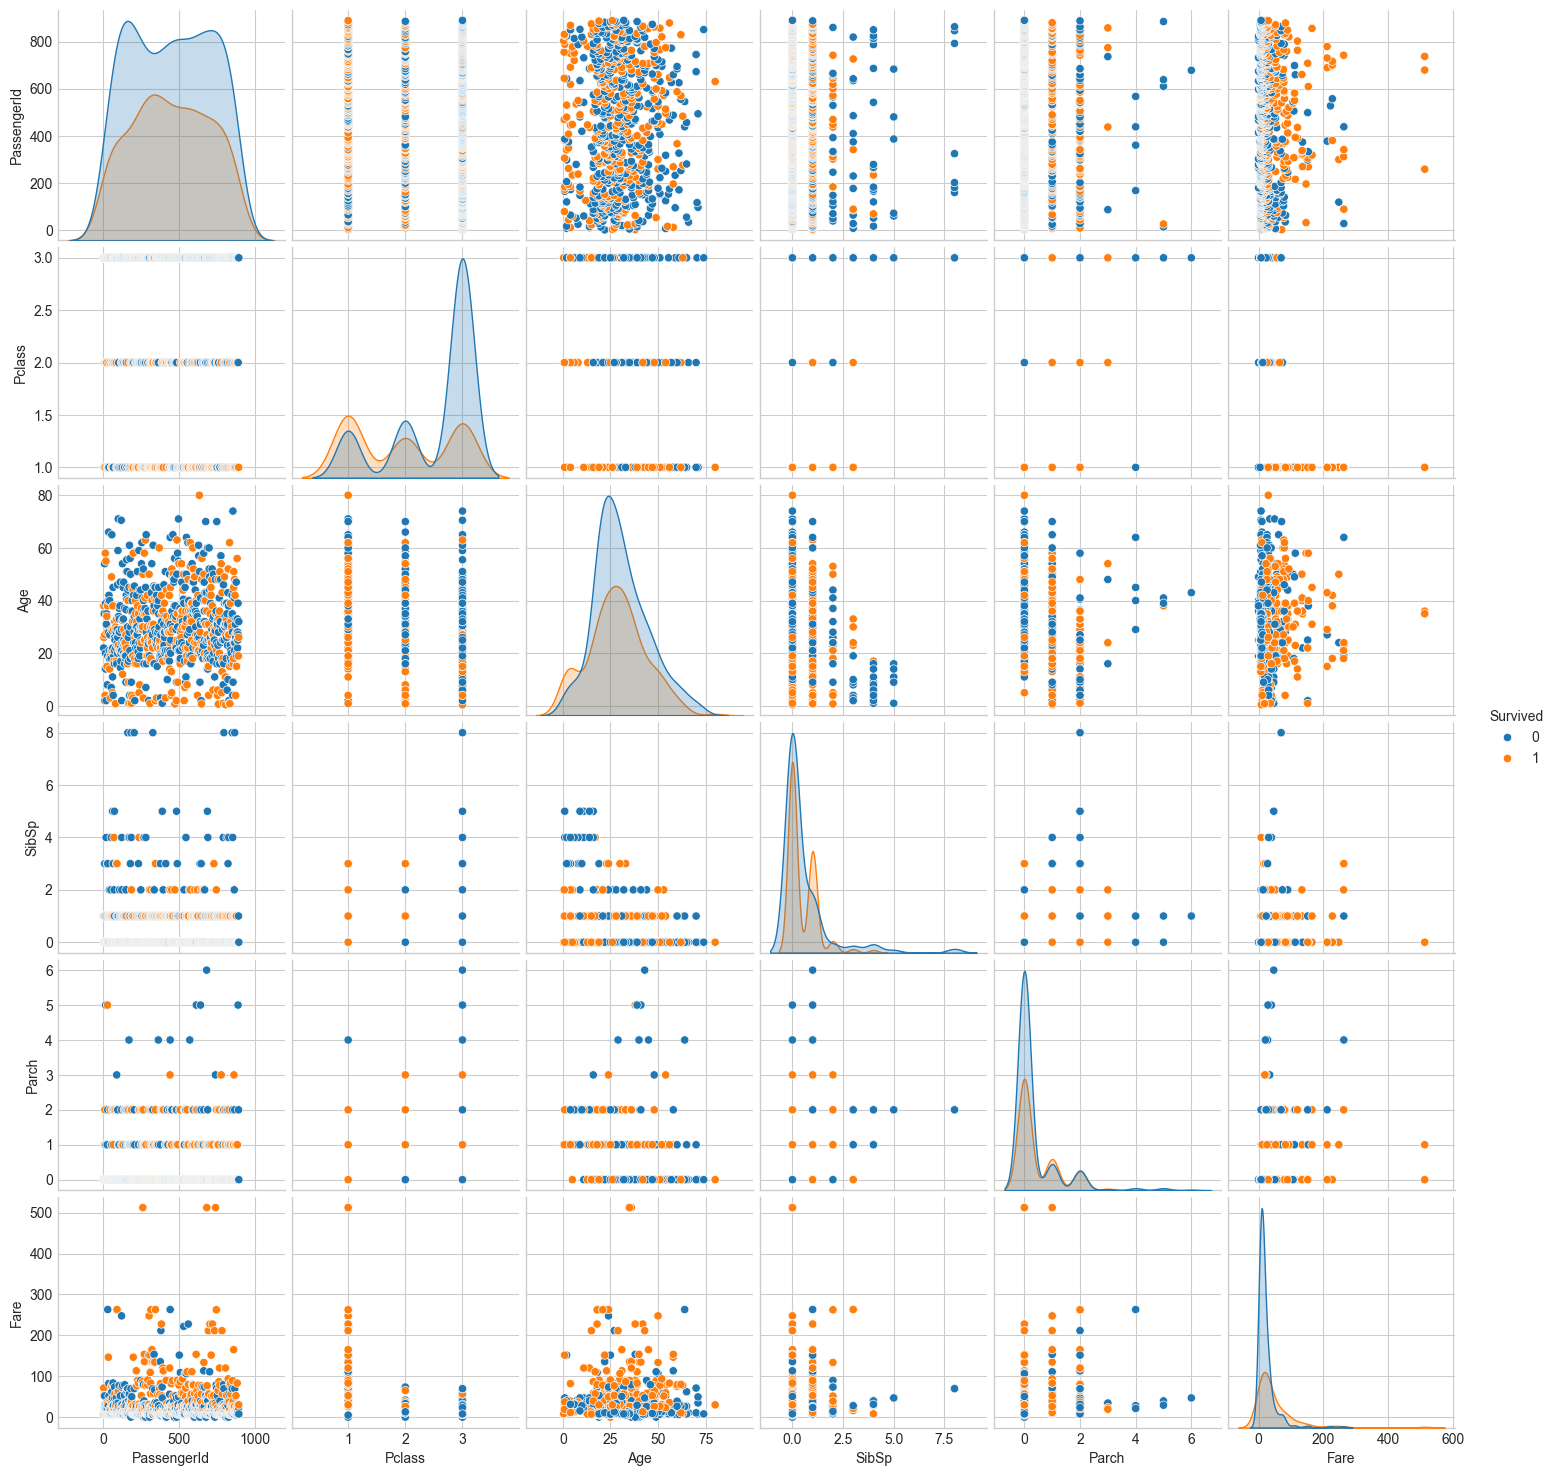

In [63]:
sns.pairplot(df, hue='Survived')

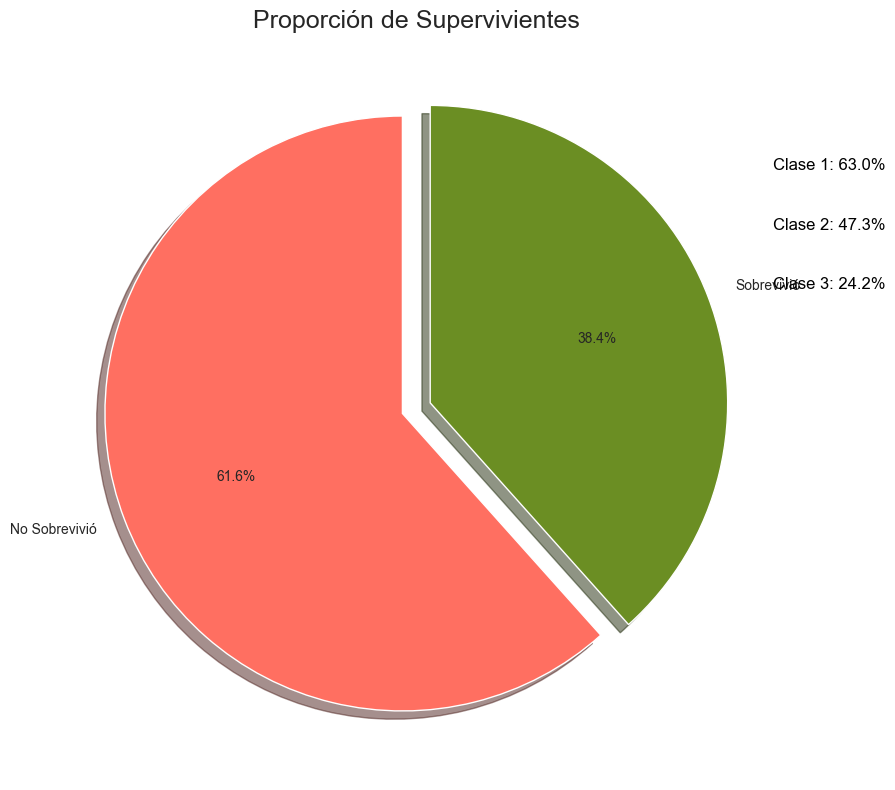

In [68]:
# Calcular la proporción de supervivientes y no supervivientes
supervivencia = df['Survived'].value_counts()

# Crear el gráfico de pastel
plt.figure(figsize=(10, 8))
plt.pie(supervivencia, 
    labels=['No Sobrevivió', 'Sobrevivió'], 
    autopct='%1.1f%%', 
    colors=['#FF6F61', '#6B8E23'], 
    startangle=90, 
    explode=(0.05, 0.05), 
    shadow=True)

# Añadir título
plt.title('Proporción de Supervivientes', fontsize=18)

# Añadir información adicional sobre la supervivencia por clase
for pclass, porcentaje in supervivientes_por_clase.items():
    plt.annotate(f'Clase {pclass}: {porcentaje:.1f}%', 
         xy=(1.2, 1 - 0.2 * pclass), 
         fontsize=12, 
         color='black')

plt.tight_layout()
plt.show()

### Plotly express (Interactivos)

In [71]:
import plotly.io as pio

In [72]:
px.pie(df,
       values='Survived',
       names='Pclass',
       template='plotly_dark',
       title='Supervivencia por clase',)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
              'hovertemplate': 'Pclass=%{label}<br>Survived=%{value}<extra></extra>',
              'labels': {'bdata': ('AwEDAQMDAQMDAgMBAwMDAgMCAwMCAg' ... 'MDAwEBAwIDAwMDAQIDAwIDAwIBAwED'),
                         'dtype': 'i1'},
              'legendgroup': '',
              'name': '',
              'showlegend': True,
              'type': 'pie',
              'values': {'bdata': ('AAEBAQAAAAABAQEBAAAAAQABAAEAAQ' ... 'ABAAEAAAEBAAAAAQEAAAAAAAABAAEA'),
                         'dtype': 'i1'}}],
    'layout': {'legend': {'tracegroupgap': 0}, 'template': '...', 'title': {'text': 'Supervivencia por clase'}}
})